In [1]:
#Make Gaussian
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D
import math
import numpy as np

def py_bivariate_normal_pdf(domain, mean, variance):
    X = [[-mean+x*variance for x in range(int((-domain+mean)//variance), 
                                                   int((domain+mean)//variance)+1)] 
                  for _ in range(int((-domain+mean)//variance), 
                                 int((domain+mean)//variance)+1)]
    Y = [*map(list, zip(*X))]
    R = [[math.sqrt(a**2 + b**2) for a, b in zip(c, d)] for c, d in zip(X, Y)]
    Z = [[(1. / math.sqrt(2 * math.pi)) * math.exp(-.5*r**2) for r in r_sub] for r_sub in R]
    X = [*map(lambda a: [b+mean for b in a], X)]
    Y = [*map(lambda a: [b+mean for b in a], Y)]
    return  np.array(X), np.array(Y), np.array(Z)


def plt_plot_bivariate_normal_pdf(x, y, z):
  fig = plt.figure(figsize=(12, 6))
  ax = fig.gca(projection='3d')
  ax.scatter(x, y, z, 
                  cmap=cm.coolwarm,
                  linewidth=0, 
                  antialiased=True,s=5)
  ax.set_xlabel('x')
  ax.set_ylabel('y')
  ax.set_zlabel('z');
  plt.show()


plt_plot_bivariate_normal_pdf(*py_bivariate_normal_pdf(6, 0, .2))

<Figure size 1200x600 with 1 Axes>

In [2]:
#A center (1,0,0)-Faulty   X center(0,0,0)- Normal
A=py_bivariate_normal_pdf(10,0,.1)
X=py_bivariate_normal_pdf(10,0,.1)

In [3]:
A=np.asarray(A)
X=np.asarray(X)
B=A[0]+1
A[0]=B        #A의 x 축 +1

a_res = A.reshape(3, A.shape[1]**2)
x_res=X.reshape(3,X.shape[1]**2)
top=a_res[2]>0.02
tp=x_res[2]>0.02      # 바닥 점들 제거

a_res2=a_res[:,top]
x_res2=x_res[:,tp]

In [4]:
a_res2.shape

(3, 1885)

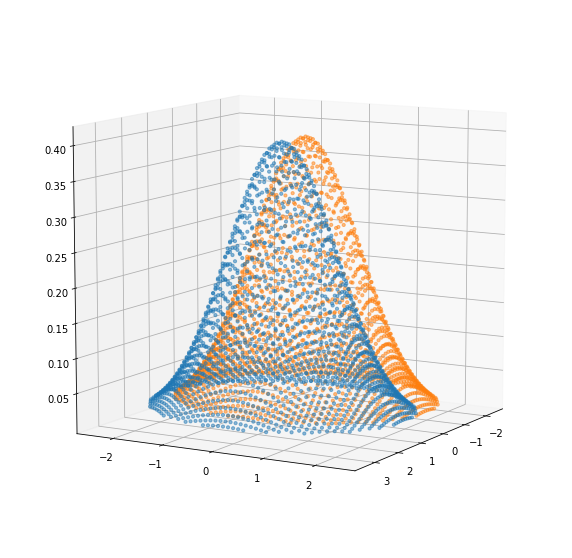

In [5]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np 

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d') # Axe3D object

ax.scatter(a_res2[0],a_res2[1],a_res2[2], s= 10, alpha=0.5, cmap=plt.cm.Greens)
ax.scatter(x_res2[0],x_res2[1],x_res2[2], s= 10, alpha=0.5, cmap=plt.cm.Greens)
ax.view_init(10,30) # rotate plot
plt.show()

In [9]:
import matplotlib.pyplot as plt
import numpy as np

from mpl_toolkits.mplot3d import Axes3D
from pydiffmap import diffusion_map as dm

%matplotlib inline

# initialize Diffusion map object.
#neighbor_params = {'n_jobs': -1, 'algorithm': 'kd_tree'}
neighbor_params = {'n_jobs': -1, 'algorithm': 'ball_tree'}

#mydmap_P = dm.DiffusionMap.from_sklearn(n_evecs=2, k=1880, epsilon='bgh_generous', alpha=1, neighbor_params=neighbor_params)
#mydmap_Q = dm.DiffusionMap.from_sklearn(n_evecs=2, k=1880, epsilon='bgh_generous', alpha=1, neighbor_params=neighbor_params)
#a= normalize  epsilon=distance distribution
mydmap_P = dm.DiffusionMap.from_sklearn(n_evecs=2, k=1880,alpha=1,epsilon='bgh')
mydmap_Q = dm.DiffusionMap.from_sklearn(n_evecs=2, k=1880,alpha=1,epsilon='bgh')



In [8]:
!pip install pyDiffMap

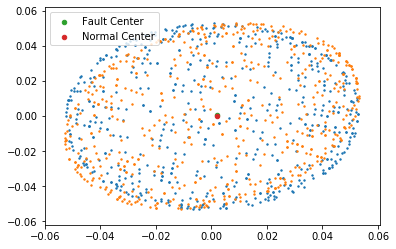

In [10]:
P=np.transpose(a_res2)  #Fault Data
Q=np.transpose(x_res2)  #Normal Data
R=np.random.choice(1880,600)
# fit to data and return the diffusion map.
'''
dmap_P = mydmap_P.fit_transform(P)
dmap_Q=  mydmap_Q.fit_transform(Q)
centroid_P = dmap_P.mean(axis=0)
centroid_Q = dmap_Q.mean(axis=0)
scatter=plt.scatter(dmap_P[:,0],dmap_P[:,1],s=2)
plt.scatter(dmap_Q[:,0],dmap_Q[:,1],s=2)
plt.scatter(centroid_P[0],centroid_P[1],s=20,label='Fault Center')
plt.scatter(centroid_Q[0],centroid_Q[1],s=20,label='Normal Center')
'''
dmap_P = mydmap_P.fit_transform(P)
dmap_Q=  mydmap_Q.fit_transform(Q)
centroid_P = dmap_P[R].mean(axis=0)
centroid_Q = dmap_Q[R].mean(axis=0)
scatter=plt.scatter(dmap_P[R,0],dmap_P[R,1],s=2)
plt.scatter(dmap_Q[R,0],dmap_Q[R,1],s=2)
plt.scatter(centroid_P[0],centroid_P[1],s=20,label='Fault Center')
plt.scatter(centroid_Q[0],centroid_Q[1],s=20,label='Normal Center')
plt.legend()
plt.show()

In [11]:
#Sample Basline Data from Normal Data
Base=Q[np.random.choice(1885,100)]


In [12]:
Base.shape

(100, 3)

In [13]:
Base_dm = dm.DiffusionMap.from_sklearn(n_evecs=2, k=100, 
                                        epsilon='bgh', alpha=1, neighbor_params=neighbor_params)
Base_dm.fit_transform(Base)
Base_Ev=Base_dm.evals
print(Base_Ev)

[-0.38551318 -0.49172528]


In [19]:
DF_dm = dm.DiffusionMap.from_sklearn(n_evecs=2, k=200, 
                                        epsilon='bgh', alpha=1, neighbor_params=neighbor_params)
DT_dm = dm.DiffusionMap.from_sklearn(n_evecs=2, k=200, 
                                        epsilon='bgh', alpha=1, neighbor_params=neighbor_params)

In [20]:
#Faulty Ev
Fau_Ev=[]
for i in range(50):
    #Dt_Fau=P[np.random.choice(577,100)]
    Dt_Fau=np.vstack([Base,P[np.random.choice(1880,100)]])
    #Dt_Fau=np.random.permutation(Dt_Fau)
    DF_dm.fit_transform(Dt_Fau)
    Fau_Ev.append(DF_dm.evals)
Fau_Ev=np.asarray(Fau_Ev)

In [21]:
Fau_Ev.shape

(50, 2)

In [22]:
#Normal EV
Nor_Ev=[]
for i in range(50):
    #Dt_Nor=Q[np.random.choice(577,100)]
    Dt_Nor=np.vstack([Base,Q[np.random.choice(1880,100)]])
    #Dt_Nor=np.random.permutation(Dt_Nor)
    DT_dm.fit_transform(Dt_Nor)
    Nor_Ev.append(DT_dm.evals)
Nor_Ev=np.asarray(Nor_Ev)

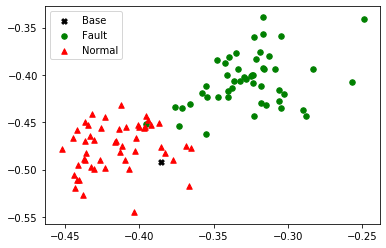

In [23]:
plt.scatter(Base_Ev[0],Base_Ev[1],s=30,c="Black",label='Base',marker='X')
plt.scatter(Fau_Ev[:,0],Fau_Ev[:,1],s=30,c='Green',label='Fault',marker='o')
plt.scatter(Nor_Ev[:,0],Nor_Ev[:,1],s=30,c="Red",label='Normal',marker='^')
plt.legend()
plt.show()

In [39]:
a = np.arange(20).reshape(4,5)

In [40]:
a

array([[ 0,  1,  2,  3,  4],
       [ 5,  6,  7,  8,  9],
       [10, 11, 12, 13, 14],
       [15, 16, 17, 18, 19]])

In [41]:
np.random.permutation(a)

array([[15, 16, 17, 18, 19],
       [10, 11, 12, 13, 14],
       [ 0,  1,  2,  3,  4],
       [ 5,  6,  7,  8,  9]])

In [16]:
import numpy as np

In [17]:
A = np.arange(25).reshape(5,5)

In [18]:
A

array([[ 0,  1,  2,  3,  4],
       [ 5,  6,  7,  8,  9],
       [10, 11, 12, 13, 14],
       [15, 16, 17, 18, 19],
       [20, 21, 22, 23, 24]])

In [19]:
np.linalg.eig(A)

(array([ 6.39116499e+01, -3.91164992e+00, -4.06523933e-15,  2.58443073e-16,
         1.51528038e-15]),
 array([[-0.0851802 ,  0.67779864, -0.46549901,  0.18772213, -0.00207481],
        [-0.23825372,  0.36348873,  0.55597991, -0.0514454 , -0.41636356],
        [-0.39132723,  0.04917881, -0.15590518, -0.65194893,  0.2955311 ],
        [-0.54440074, -0.2651311 ,  0.50586667,  0.70734553,  0.66632773],
        [-0.69747425, -0.57944101, -0.44044239, -0.19167334, -0.54342046]]))

In [20]:
B = np.random.permutation(A)

In [21]:
B

array([[15, 16, 17, 18, 19],
       [20, 21, 22, 23, 24],
       [ 5,  6,  7,  8,  9],
       [ 0,  1,  2,  3,  4],
       [10, 11, 12, 13, 14]])

In [22]:
np.linalg.eig(B)

(array([ 5.73861279e+01, -2.27503123e-14,  2.61387212e+00,  5.98571948e-16,
        -5.51521664e-16]),
 array([[-0.54662527, -0.41833001,  0.34834023, -0.51595419,  0.42781647],
        [-0.71249824,  0.7768986 ,  0.6637073 ,  0.23677801, -0.51017697],
        [-0.21487933, -0.11952286, -0.2823939 ,  0.5186471 ,  0.19024736],
        [-0.04900636, -0.41833001, -0.59776096,  0.31618854, -0.56122968],
        [-0.3807523 ,  0.17928429,  0.03297317, -0.55565946,  0.45334282]]))